In [1]:
from database.adatabase import ADatabase
from processor.processor import Processor as processor
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")

In [2]:
market = ADatabase("market")

In [3]:
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [4]:
factors = ["GOOGL"]

In [5]:
market.connect()
factor_dfs = []
for ticker in factors:
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","ticker","adjclose"]]
        factor_dfs.append(ticker_prices)
    except:
        print(ticker)
        continue
factor_df = pd.concat(factor_dfs).pivot_table(index="date",columns="ticker",values="adjclose").reset_index()

In [6]:
factor_df

ticker,date,GOOGL
0,2022-01-03 05:00:00+00:00,144.99
1,2022-01-04 05:00:00+00:00,144.40
2,2022-01-05 05:00:00+00:00,137.78
3,2022-01-06 05:00:00+00:00,137.75
4,2022-01-07 05:00:00+00:00,137.02
...,...,...
496,2023-12-22 05:00:00+00:00,141.49
497,2023-12-26 05:00:00+00:00,141.52
498,2023-12-27 05:00:00+00:00,140.37
499,2023-12-28 05:00:00+00:00,140.23


In [7]:
market.connect()
sim = []
for ticker in tqdm(russell1000["ticker"].values):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","weekday","ticker","adjclose"]]
        ticker_prices = processor.merge(ticker_prices,factor_df.copy(),on="date")
        training_data = ticker_prices.iloc[:100]
        simulation_data = ticker_prices.iloc[100:]
        for factor in factors:
            covariance = training_data["adjclose"].cov(training_data[factor])
            simulation_data[f"{factor}_beta"] = covariance / simulation_data[factor].rolling(100).var()
            simulation_data[f"{factor}_loading"] = simulation_data[factor] * simulation_data[f"{factor}_beta"]
        simulation_data["expected_value"] = [sum([row[1][f"{factor}_loading"] for factor in factors]) for row in simulation_data.iterrows()]
        simulation_data["return"] = (simulation_data["adjclose"].shift(-5) - simulation_data["adjclose"].shift(-1)) / simulation_data["adjclose"].shift(-1)
        sim.append(simulation_data[["date","weekday","ticker","expected_value","return"]])
    except Exception as e:
        print(str(e))
market.disconnect()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [02:21<00:00,  7.13it/s]


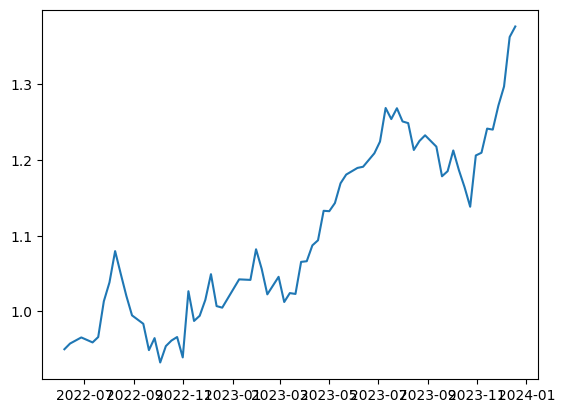

In [8]:
positions = 10 
simulation = pd.concat(sim)
trades = simulation[simulation["weekday"]==0]
trades["return"] = trades["return"] * 0.1
trades["return"] = [max(-.005,x) for x in trades["return"]]
trades = trades.sort_values("expected_value",ascending=False).groupby("date").nth([i for i in range(positions)])
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.show()